In [5]:
import numpy as np
import pandas as pd

In [6]:
df = pd.read_csv('/content/cars.csv')

In [7]:
df.head()

,brand,km_driven,fuel,owner,selling_price
0,Maruti,145500,Diesel,First Owner,450000
1,Skoda,120000,Diesel,Second Owner,370000
2,Honda,140000,Petrol,Third Owner,158000
3,Hyundai,127000,Diesel,First Owner,225000
4,Maruti,120000,Petrol,First Owner,130000


**One HotEncoing By using Pandas**

In [8]:
df['brand'].value_counts()

,count
brand,
Maruti,2448
Hyundai,1415
Mahindra,772
Tata,734
Toyota,488
Honda,467
Ford,397
Chevrolet,230
Renault,228


In [11]:
df['fuel'].value_counts()

,count
fuel,
Diesel,4402
Petrol,3631
CNG,57
LPG,38


In [16]:
pd.get_dummies(df,columns=['fuel','owner'],dtype=int)

,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,0,1,0,0,1,0,0,0,0
1,Skoda,120000,370000,0,1,0,0,0,0,1,0,0
2,Honda,140000,158000,0,0,0,1,0,0,0,0,1
3,Hyundai,127000,225000,0,1,0,0,1,0,0,0,0
4,Maruti,120000,130000,0,0,0,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,0,0,0,1,1,0,0,0,0
8124,Hyundai,119000,135000,0,1,0,0,0,1,0,0,0
8125,Maruti,120000,382000,0,1,0,0,1,0,0,0,0
8126,Tata,25000,290000,0,1,0,0,1,0,0,0,0


In [21]:
pd.get_dummies(df,columns=['fuel','owner'],dtype=bool)

,brand,km_driven,selling_price,fuel_CNG,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,False,True,False,False,True,False,False,False,False
1,Skoda,120000,370000,False,True,False,False,False,False,True,False,False
2,Honda,140000,158000,False,False,False,True,False,False,False,False,True
3,Hyundai,127000,225000,False,True,False,False,True,False,False,False,False
4,Maruti,120000,130000,False,False,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,False,True,True,False,False,False,False
8124,Hyundai,119000,135000,False,True,False,False,False,True,False,False,False
8125,Maruti,120000,382000,False,True,False,False,True,False,False,False,False
8126,Tata,25000,290000,False,True,False,False,True,False,False,False,False


# k-1 OneHotEncoding

In [22]:
pd.get_dummies(df,columns=['fuel','owner'],drop_first=True)

,brand,km_driven,selling_price,fuel_Diesel,fuel_LPG,fuel_Petrol,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,Maruti,145500,450000,True,False,False,False,False,False,False
1,Skoda,120000,370000,True,False,False,False,True,False,False
2,Honda,140000,158000,False,False,True,False,False,False,True
3,Hyundai,127000,225000,True,False,False,False,False,False,False
4,Maruti,120000,130000,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
8123,Hyundai,110000,320000,False,False,True,False,False,False,False
8124,Hyundai,119000,135000,True,False,False,True,False,False,False
8125,Maruti,120000,382000,True,False,False,False,False,False,False
8126,Tata,25000,290000,True,False,False,False,False,False,False


# OneHotEncoding Using Sklearn

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.iloc[:,0:4],df.iloc[:,-1],test_size=0.2,random_state=2)

In [24]:
X_train.head()

,brand,km_driven,fuel,owner
5571,Hyundai,35000,Diesel,First Owner
2038,Jeep,60000,Diesel,First Owner
2957,Hyundai,25000,Petrol,First Owner
7618,Mahindra,130000,Diesel,Second Owner
6684,Hyundai,155000,Diesel,First Owner


In [25]:
from sklearn.preprocessing import OneHotEncoder

In [26]:
ohe=OneHotEncoder()

In [32]:
X_train_new= ohe.fit_transform(X_train[['fuel','owner']]).toarray()

In [33]:
X_train_new

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [34]:
X_train_new.shape

(6502, 9)

drop first column for Multicollinearity

In [40]:
ohe=OneHotEncoder(drop='first')

In [52]:
X_train_new= ohe.fit_transform(X_train[['fuel','owner']]).toarray()

In [53]:
X_train_new

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]])

In [44]:
X_train_new.shape

(6502, 7)

# OneHotEncoding with top categories

In [59]:
counts=df['brand'].value_counts()

In [60]:
counts

,count
brand,
Maruti,2448
Hyundai,1415
Mahindra,772
Tata,734
Toyota,488
Honda,467
Ford,397
Chevrolet,230
Renault,228


In [57]:
df['brand'].nunique()
threshold= 100

In [61]:
repl=counts[counts <=threshold ].index

In [72]:
new=pd.get_dummies(df['brand'].replace(repl,'uncommon'),dtype=int)

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

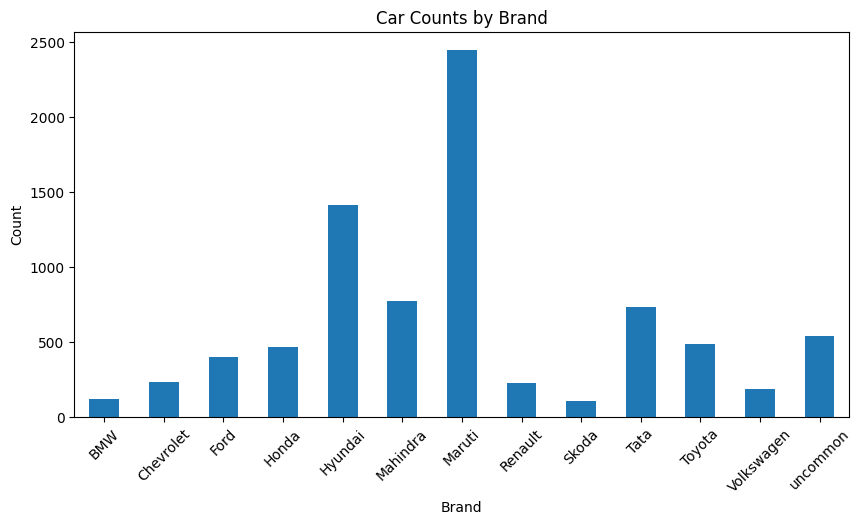

In [75]:
import matplotlib.pyplot as plt

brand_counts = new.sum()

# Plot as a bar chart
brand_counts.plot(kind='bar', figsize=(10,5))

plt.title('Car Counts by Brand')
plt.xlabel('Brand')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


# Column Transformer

In [78]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

In [81]:
df=pd.read_csv('/content/covid_toy.csv')

In [83]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df.drop(columns=['has_covid']),df['has_covid'],test_size= 0.2)

In [85]:
X_test

,age,gender,fever,cough,city
71,75,Female,104.0,Strong,Delhi
46,19,Female,101.0,Mild,Mumbai
47,18,Female,104.0,Mild,Bangalore
17,40,Female,98.0,Strong,Delhi
99,10,Female,98.0,Strong,Kolkata
58,23,Male,98.0,Strong,Mumbai
95,12,Female,104.0,Mild,Bangalore
85,16,Female,103.0,Mild,Bangalore
23,80,Female,98.0,Mild,Delhi
35,82,Female,102.0,Strong,Bangalore


In [86]:
from sklearn.compose import ColumnTransformer

In [92]:
transformer =ColumnTransformer(transformers=[
    ('tnf1',SimpleImputer(),['fever']),
    ('tnf2',OrdinalEncoder(categories=[['Mild','Strong']]),['cough']),
    ('tnf3',OneHotEncoder(sparse_output=False,drop='first'),['gender','city'])


],remainder='passthrough'
)

In [93]:
transformer.fit_transform(X_train).shape

(80, 7)

In [94]:
transformer.fit_transform(X_test).shape


(20, 7)